#1. Environment setup

In [ ]:
!pip install langchain-graphrag==0.0.9 graspologic networkx langchain-ollama langchain-community langchain

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
spath = '/content/drive/My Drive/genaiproj/save'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#2. LLM configuration

In [ ]:
!sudo apt update
!sudo apt install -y pciutils
!sudo apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [87.4 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,452 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-

In [ ]:
import threading
import subprocess
import time

def run_ollama_serve():
  subprocess.Popen(["ollama", "serve"])

thread = threading.Thread(target=run_ollama_serve)
thread.start()
time.sleep(5)

In [ ]:
!ollama pull mistral:7b
!ollama list


NAME          ID              SIZE      MODIFIED               
mistral:7b    6577803aa9a0    4.4 GB    Less than a second ago    


### patch for langchain.output_parser

In [ ]:
import os
# Path to the problematic file within langchain_graphrag
file_to_patch = '/usr/local/lib/python3.12/dist-packages/langchain_graphrag/indexing/report_generation/_output_parser.py'

# Check if the file exists
if os.path.exists(file_to_patch):
    print(f"Patching: {file_to_patch}")
    with open(file_to_patch, 'r') as f:
        content = f.read()

    # Replace the old import with the new one
    # Only patch if the old import line is present and the new one is not already there
    old_import = 'from langchain.output_parsers import PydanticOutputParser'
    new_import = 'from langchain_core.output_parsers import PydanticOutputParser'

    if old_import in content and new_import not in content:
        content = content.replace(old_import, new_import)
        with open(file_to_patch, 'w') as f:
            f.write(content)
        print("Successfully patched langchain_graphrag for output_parsers compatibility.")
    elif new_import in content:
        print("Patch already applied.")
    else:
        print("Old import line not found, no patch applied (or file structure changed unexpectedly).")
else:
    print(f"File not found: {file_to_patch}. Manual patching may be required or the environment is different.")

Patching: /usr/local/lib/python3.12/dist-packages/langchain_graphrag/indexing/report_generation/_output_parser.py
Successfully patched langchain_graphrag for output_parsers compatibility.


In [ ]:
from langchain_ollama import ChatOllama
from langchain_community.cache import SQLiteCache

PATH_FOLDER = '/content/drive/MyDrive/genaiproj/save'
llm_model = "mistral:7b"
print(f"Initializing model {llm_model}...")
llm = ChatOllama(model=llm_model, temperature=0, seed=42)


Initializing model mistral:7b...


#3. Load master graph and communities

In [ ]:
import os
import pickle
import networkx as nx

# Load master graph
master_path = os.path.join(spath, 'master_graph_all.pkl')

if os.path.exists(master_path):
    with open(master_path, 'rb') as f:
        final_graph = pickle.load(f)
    print(f"✅ Success! Loaded Master Graph with {final_graph.number_of_nodes()} nodes.")
else:
    print("❌ Error: File not found. Check your Drive path.")

✅ Success! Loaded Master Graph with 4593 nodes.


In [ ]:
# Look at one random node's data
sample_node = list(final_graph.nodes(data=True))[0]
print(f"Sample Node: {sample_node}")

Sample Node: ('HYPOGLYCEMIA', {'type': 'EVENT', 'description': "Here is a comprehensive summary of the data provided:\n\n**HYPOGLYCEMIA**\n\nHypoglycemia is a medical condition characterized by low blood sugar levels that can occur in individuals with diabetes, including those with type 2 diabetes and dementia. It is a complication of diabetes that can have serious consequences if left untreated. In some cases, hypoglycemia may not occur until several hours later.\n\nHypoglycemia is often defined as a condition where an individual's blood glucose level falls below the normal range, requiring medical attention. It is characterized by low blood sugar levels and can cause symptoms such as shakiness, sweating, and dizziness.\n\nAs a complication of diabetes, hypoglycemia may be a potential side effect of diabetes medication or insulin therapy. In some cases, it can occur when insulin levels are too high or with certain types of insulin. It is essential to manage diabetes effectively to pre

In [ ]:
import pandas as pd
import os

# Load the summarized dataframe
spath = '/content/drive/MyDrive/genaiproj/save'
load_path = os.path.join(spath, 'df_communities_summarized_all.pkl')

df_communities = pd.read_pickle(load_path)
print(f"✅ Loaded {len(df_communities)} summarized communities!")

✅ Loaded 1406 summarized communities!


#4. Local Search

In [ ]:
import re
def local_search(query: str, final_graph, llm, top_k=5):
    print(f"Executing Local Search for: '{query}'")

    query_words = set(re.findall(r'\b\w+\b', query.lower()))

    # Entity matching
    matched_nodes = []
    for node in final_graph.nodes():
        if str(node).lower() in query.lower():
            matched_nodes.append(node)

    print(f"Detected query entities: {matched_nodes}")

    if not matched_nodes:
        return "I couldn't find any specific entities in your query to search the graph for. Try rephrasing with specific terms from the paper."

    # Extract the local neigborhood
    context_relationships = []
    for node in matched_nodes[:top_k]:
        all_edges = list(final_graph.edges(node, data=True))
        for u, v, data in all_edges[:15]: # Limiting to 15 edges
            context_relationships.append(f"{u} --[{data.get('label', 'related_to')}]-- {v}")

    # Prompt construction
    context_str = "\n".join(set(context_relationships))

    prompt_template = f"""
    You are a helpful medical assistant. Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know. Do not make up information.


    Context:
    {context_str}


    Question:
    {query}


    Answer:
    """

    edges = context_relationships

    format_edges = "Retrieved Relationships:\n" + "\n".join(edges)

    print("Querying Ollama...")
    response = llm.invoke(prompt_template)
    return response.content, [format_edges]

# Test with one query
print("-----")
test_query = "Does diabetes associate with cataract?"
print(local_search(test_query, final_graph, llm))

-----
Executing Local Search for: 'Does diabetes associate with cataract?'
Detected query entities: ['DIABETES', 'TAR', 'C', 'AR', 'E', 'A', 'B', 'RA', 'R', '']
Querying Ollama...
(' Based on the provided context, there is no direct association mentioned between "DIABETES" and "cataract." However, it\'s important to note that diabetes can increase the risk of various eye diseases, including cataracts. For a definitive answer regarding this specific association, further research or consultation with a healthcare professional would be necessary.', ['Retrieved Relationships:\nDIABETES --[related_to]-- A1C\nDIABETES --[related_to]-- BLOOD GLUCOSE MONITORING (BGM)\nDIABETES --[related_to]-- TIR\nDIABETES --[related_to]-- CGM\nDIABETES --[related_to]-- METRIC INTERPRETATION GOALS METRICS\nDIABETES --[related_to]-- PREGNANCY\nDIABETES --[related_to]-- AMERICAN DIABETES ASSOCIATION\nDIABETES --[related_to]-- METFORMIN THERAPY\nDIABETES --[related_to]-- INITIATION\nDIABETES --[related_to]-- DCC

#5. Global search

In [ ]:
import re

def global_search(query: str, df_comms, llm, top_n=3):

    print(f"Executing Global Search for: '{query}'")

    # Clean and tokenize the user's query into a set of lowercase keywords
    query_words = set(re.findall(r'\b\w+\b', query.lower()))
    stop_words = {'what', 'are', 'the', 'in', 'a', 'with', 'to', 'how', 'does', 'is', 'of'} # (Ignoring common tiny words like 'the', 'is', 'a')
    search_terms = query_words - stop_words

    # Score every community summary based on how many search terms it contains
    def score_summary(summary_text):
        if not isinstance(summary_text, str) or "Error" in summary_text:
            return 0
        summary_lower = summary_text.lower()
        # Count how many of the query keywords appear in this summary
        score = sum(1 for word in search_terms if word in summary_lower)
        return score

    # Create a new column with the relevance score
    df_comms['relevance_score'] = df_comms['summary'].apply(score_summary)

    # Sorting communities by relevancy score
    sorted_df = df_comms.sort_values(by=['relevance_score', 'size'], ascending=[False, False])

    valid_summaries = []
    for index, row in sorted_df.iterrows():
        summary = row.get('summary', '')
        score = row.get('relevance_score', 0)

        # If relevance score 0 then skip
        if isinstance(summary, str) and len(summary) > 20:
            valid_summaries.append(f"[Relevance: {score}] Theme {len(valid_summaries)+1}: {summary}")

        if len(valid_summaries) >= top_n:
            break

    print(f"Loaded {len(valid_summaries)} highly relevant community themes for context.")

    if not valid_summaries:
        return "No community summaries available.", []

    # Constructing prompt
    context_str = "\n\n".join(valid_summaries)

    prompt_template = f"""
    You are a helpful medical assistant. Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know. Do not make up information.

    Context:
    {context_str}

    Question:
    {query}

    Answer:
    """

    print("Synthesizing final answer with Ollama (Llama)...")
    response = llm.invoke(prompt_template)
    df_comms.drop(columns=['relevance_score'], inplace=True, errors='ignore')
    return response.content, valid_summaries

# 6. Loop to generate answer for evaluation

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/genaiproj/evaluation.xlsx'
sheet_name = 'graphrag-llama'
df_eval = pd.read_excel(file_path, sheet_name=sheet_name)

generated_answers = []
retrieved_contexts = []
latency = []

print(f"Starting batch generation for {len(df_eval)} questions on the {sheet_name} sheet...")

for index, row in df_eval.iterrows():
    question = row['Question']
    print(f"Processing Q{index + 1}: {question}")

    start = time.time()

    # Run local search loop
    answer, contexts = local_search(question, final_graph, llm)

    # Run global search loop
    # answer, contexts = global_search(question, df_communities, llm)

    # Calculating latency
    end_time = time.time()
    latency_time = end_time - start

    generated_answers.append(answer)
    retrieved_contexts.append(contexts)
    latency.append(latency_time)


# Add the new columns
df_eval['Generated Answer'] = generated_answers
df_eval['Retrieved Contexts'] = retrieved_contexts
df_eval['Latency'] = latency

# Save loop
save_path = f'/content/drive/MyDrive/genaiproj/eval_graphrag_local_mistral_test1.xlsx'
df_eval.to_excel(save_path, index=False)
print(f"✅ Batch processing complete! Saved to {save_path}")

Starting batch generation for 97 questions on the graphrag-llama sheet...
Processing Q1: What are the primary tools used to assess glycemic status in a patient with diabetes?
Executing Local Search for: 'What are the primary tools used to assess glycemic status in a patient with diabetes?'
Detected query entities: ['DIABETES CARE', '2026 DIABETES CARE', 'GLYCEMIC GOALS', 'DIABETES', 'PEOPLE WITH DIABETES', 'AMERICAN DIABETES ASSOCIATION (ADA)', 'PROFESSIONAL DIABETES ORGANIZATION', 'AMERICAN DIABETES ASSOCIATION', 'ACTION IN DIABETES AND VASCULAR DISEASE: MODIFYING FACTORS FAVOR MORE STRINGENT GOAL', 'SHORT DIABETES DURATION', 'LONG DIABETES DURATION', 'PHARMACOLOGIC APPROACHES TO GLYCEMIC TREATMENT', 'DIABETES SELF-MANAGEMENT', 'INDIVIDUALS WITH DIABETES', 'PATIENT WITH DIABETES', 'TYPE 1 DIABETES', 'DIABETES SELF-MANAGEMENT EDUCATION AND SUPPORT PROGRAM', 'TRAINED DIABETES CARE AND EDUCATION SPECIALIST', 'DIABETES TREATMENT', 'DIABETES CARE AND EDUCATION SPECIALISTS', 'TYPE 2 DIABETE

#7. Drawing graph nodes

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_local_subgraph(unique_edges, title="Local Search Subgraph"):
    """
    Takes a list of edge strings like 'DIABETES --[related_to]-- INSULIN'
    and draws a visual network graph.
    """
    # Create an empty graph
    G = nx.DiGraph()

    # Parse your specific string format and build the graph
    for edge_str in unique_edges:
        try:
            # Split "A --[rel]-- B" into its three parts
            part1, part2 = edge_str.split("]--")
            node_a, rel = part1.split("--[")

            node_a = node_a.strip()
            node_b = part2.strip()
            rel = rel.strip()

            # Add to the network
            G.add_edge(node_a, node_b, label=rel)
        except Exception as e:
            # Skip any strings that don't match the exact format perfectly
            continue

    # If the graph is empty, stop here
    if G.number_of_nodes() == 0:
        print("No valid edges found to plot.")
        return

    # Set up the canvas
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=0.8, iterations=50)
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=3000, alpha=0.9, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_family='sans-serif')
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=15, alpha=0.6)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, font_color='red')

    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Executing Local Search for: 'What should always accompany CGM use, and why?'
Detected query entities: ['CGM', 'AND', 'US', 'C', 'E', 'A', 'N', '']
Querying Ollama...
Drawing the subgraph used to answer the question...


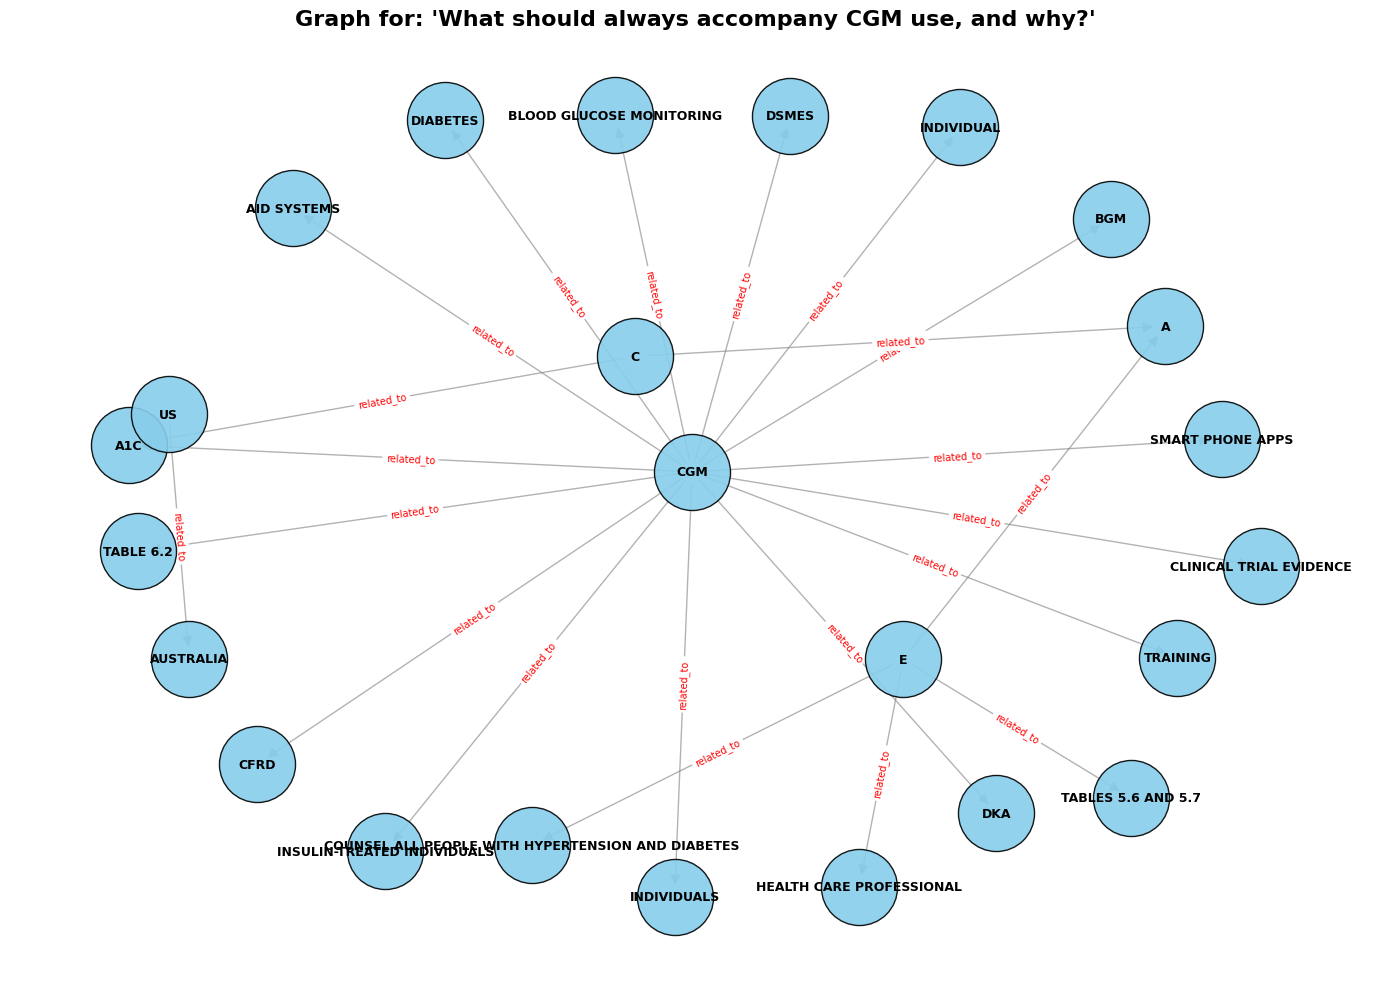

In [ ]:
test_question = "What should always accompany CGM use, and why?"

# Run search function
test_answer, test_context = local_search(test_question, final_graph, llm)

# Extract the edges back out
raw_text_block = test_context[0]
edges_for_plotting = raw_text_block.split('\n')[1:] # Skip the "Retrieved Relationships:" header

print("Drawing the subgraph used to answer the question...")
plot_local_subgraph(edges_for_plotting, title=f"Graph for: '{test_question}'")